# Capstone Project - Cards Fraud Detection # 

## _Exploratory Data Analyis (EDA) and Baseline Modelling_ ## 

# Summary #
The aim is to build an effective and robust Card Fraud Detection Model with real world IEEE dataset provided by Vesta Corporation using the CRISP-DM methodology; a model that:
- utilises engineered features,
- works with class imbalance,
- can be updated in a streamlined way and
- is readily adoptable in a realtime card detection process on a Payment Switch.

This will help us streamline the methodology, steps and resue the process on building a robust model for other cards payment data. The data has been made available freely on Kaggle(a user login is required to downlad the datasets). This data was presented in a data science competition held 7 years ago. The data comes from Vesta's real-world e-commerce transactions and contains a wide range of features from device type to product features.

## Library Imports ##

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix
from sklearn.metrics import (
    roc_curve, precision_recall_curve,
    roc_auc_score, average_precision_score
)

# EDA #
## 1. EDA: Load and merge data ##
Goal: Read the CSVs, inspect shapes, and join train_transaction and train_identity on TransactionID

In [2]:
# Set a path if running locally; in Kaggle these files can be found at https://www.kaggle.com/c/ieee-fraud-detection/data
DATA_PATH = "data/ieee-fraud-detection"

train_trans = pd.read_csv(f"{DATA_PATH}/train_transaction.csv")
train_id = pd.read_csv(f"{DATA_PATH}/train_identity.csv")

test_trans = pd.read_csv(f"{DATA_PATH}/test_transaction.csv")
test_id = pd.read_csv(f"{DATA_PATH}/test_identity.csv")

print("Train transaction shape:", train_trans.shape)
print("Train identity shape:", train_id.shape)
print("Test transaction shape:", test_trans.shape)
print("Test identity shape:", test_id.shape)

# Merge train
train = train_trans.merge(train_id, how="left", on="TransactionID")
print("Merged train shape:", train.shape)

# Merge test (for later consistency checks, not used in EDA with target)
test = test_trans.merge(test_id, how="left", on="TransactionID")
print("Merged test shape:", test.shape)

# Inspect columns
train.head()

Train transaction shape: (590540, 394)
Train identity shape: (144233, 41)
Test transaction shape: (506691, 393)
Test identity shape: (141907, 41)
Merged train shape: (590540, 434)
Merged test shape: (506691, 433)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


## 2. EDA: Basic data overview and target analysis ##
Goal: Understand the target distribution (isFraud), numerical vs categorical variables, and basic statistics.

Fraud counts:
 isFraud
0    569877
1     20663
Name: count, dtype: int64
Fraud rate: 3.4990%


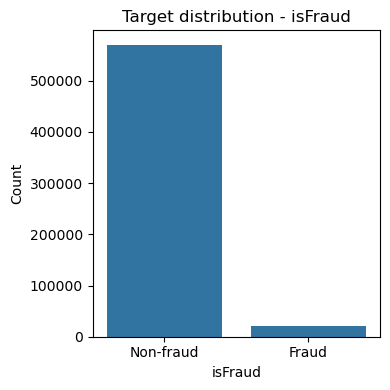

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 1.9+ GB


,count,mean,std,min,25%,50%,75%,max
TransactionID,590540.0,3.282270e+06,1.704744e+05,2987000.000,3134634.750,3282269.500,3429904.25,3.577539e+06
isFraud,590540.0,3.499001e-02,1.837546e-01,0.000,0.000,0.000,0.00,1.000000e+00
TransactionDT,590540.0,7.372311e+06,4.617224e+06,86400.000,3027057.750,7306527.500,11246620.00,1.581113e+07
TransactionAmt,590540.0,1.350272e+02,2.391625e+02,0.251,43.321,68.769,125.00,3.193739e+04
card1,590540.0,9.898735e+03,4.901170e+03,1000.000,6019.000,9678.000,14184.00,1.839600e+04
card2,581607.0,3.625555e+02,1.577932e+02,100.000,214.000,361.000,512.00,6.000000e+02
card3,588975.0,1.531949e+02,1.133644e+01,100.000,150.000,150.000,150.00,2.310000e+02
card5,586281.0,1.992789e+02,4.124445e+01,100.000,166.000,226.000,226.00,2.370000e+02
addr1,524834.0,2.907338e+02,1.017411e+02,100.000,204.000,299.000,330.00,5.400000e+02
addr2,524834.0,8.680063e+01,2.690623e+00,10.000,87.000,87.000,87.00,1.020000e+02


In [3]:
# Target distribution
fraud_counts = train['isFraud'].value_counts()
fraud_rate = fraud_counts[1] / fraud_counts.sum()

print("Fraud counts:\n", fraud_counts)
print(f"Fraud rate: {fraud_rate:.4%}")

plt.figure(figsize=(4,4))
sns.barplot(x=fraud_counts.index, y=fraud_counts.values)
plt.xticks([0,1], ['Non-fraud', 'Fraud'])
plt.title("Target distribution - isFraud")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("images/TargetDistribution_isFraud.png")
plt.show()

# Quick info and basic describe
train.info()

# Basic descriptive stats for numeric columns
train.describe().T.head(20)

List numeric vs catergorical columns:

In [4]:
#List numeric vs catergorical columns:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))

Numeric columns: 403
Categorical columns: 31


## 3. EDA: Missing values and data types ##
Goal: Understand which features are sparse and may need special treatment

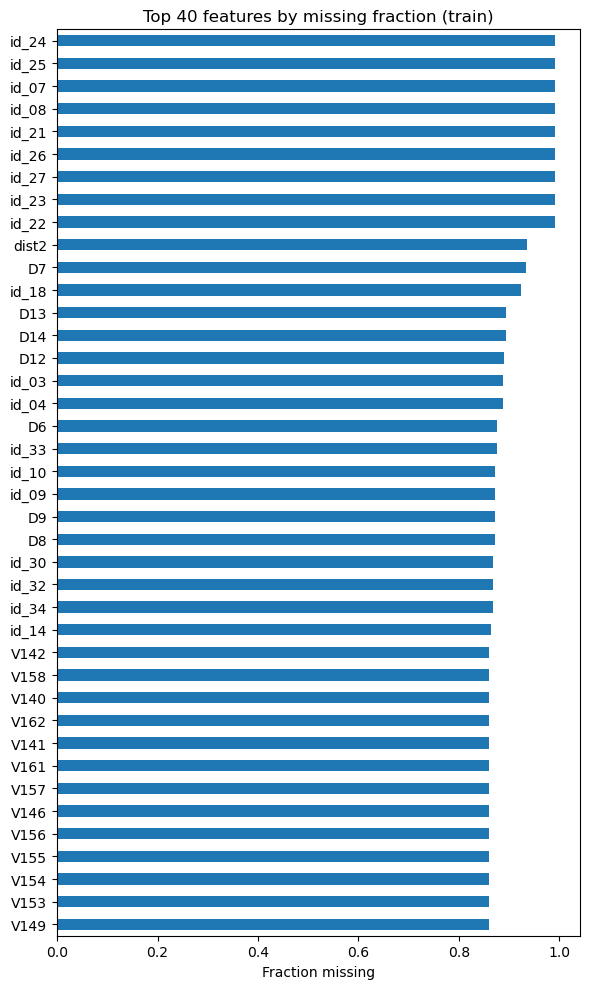

In [5]:
# Missing value fraction per column
missing_train = train.isnull().mean().sort_values(ascending=False)
missing_train.head(40)

plt.figure(figsize=(6,10))
missing_train.head(40).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 40 features by missing fraction (train)")
plt.xlabel("Fraction missing")
plt.tight_layout()
plt.savefig("images/Top40FeaturesByMissingFraction(train).png")
plt.show()

###### Export to a missingness table
missing_df = missing_train.reset_index()
missing_df.columns = ['feature', 'missing_fraction']
missing_df.to_csv("intermediate_output/missing_values_train.csv", index=False)

I also compare missingness between train and test to spot leakage‑prone features.
This helps identify columns where train/test behaviour differs strongly.

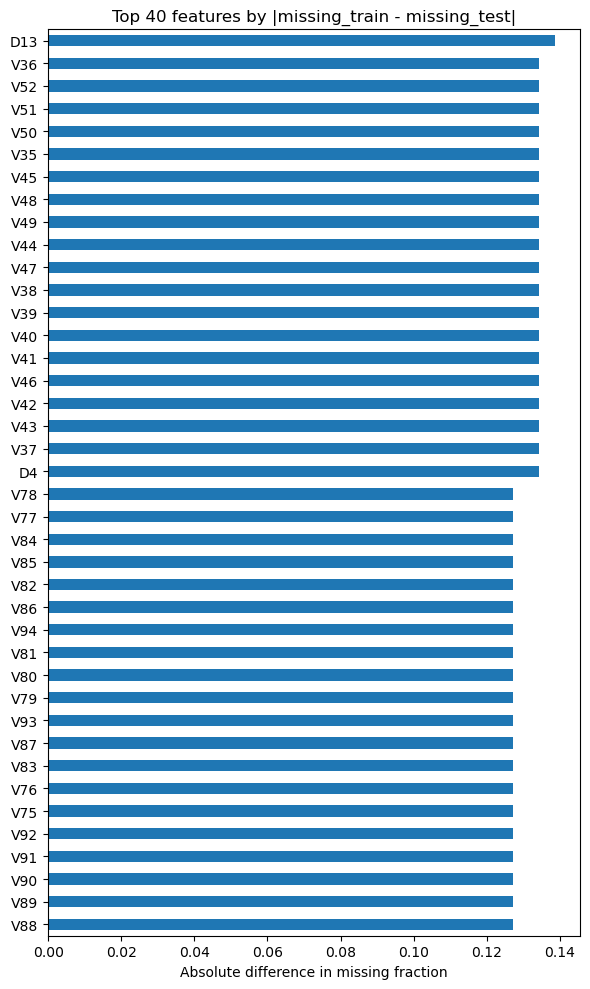

In [7]:
missing_test = test.isnull().mean()

missing_diff = (missing_train - missing_test).abs().sort_values(ascending=False)
missing_diff.head(30)

plt.figure(figsize=(6,10))
missing_diff.head(40).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 40 features by |missing_train - missing_test|")
plt.xlabel("Absolute difference in missing fraction")
plt.tight_layout()
plt.savefig("images/Top40FeaturesBy(missing_train-missing_test).png")
plt.show()

## 4. EDA: Univariate analysis: key groups of features ##
The IEEE‑CIS features are naturally grouped: transaction, card, address, email, D*, C*, M*, id*, device, V*. I will inspect a few representative variables in each group.

### 4.1 Transaction amount and time ###

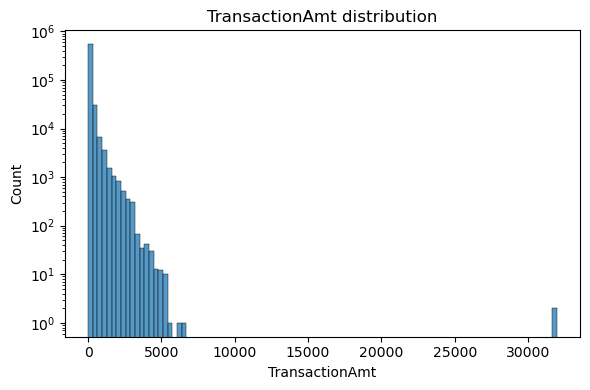

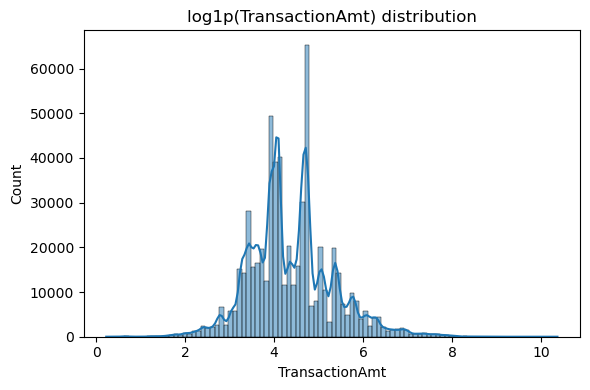

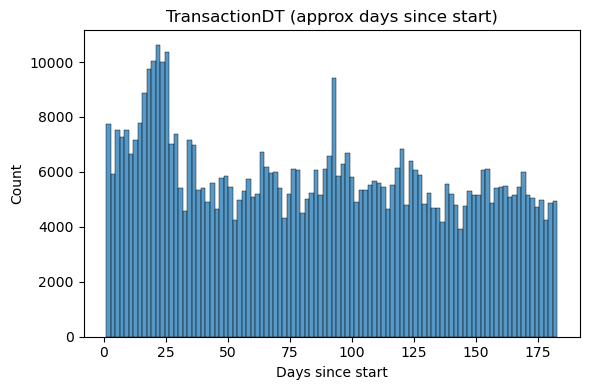

In [8]:
# TransactionAmt distribution (log scale because of heavy tail)
plt.figure(figsize=(6,4))
sns.histplot(train['TransactionAmt'], bins=100, kde=False)
plt.yscale('log')
plt.title("TransactionAmt distribution")
plt.tight_layout()
plt.savefig("images/Univariate_TransactionAmtDistribution.png")
plt.show()

# Log-transformed
plt.figure(figsize=(6,4))
sns.histplot(np.log1p(train['TransactionAmt']), bins=100, kde=True)
plt.title("log1p(TransactionAmt) distribution")
plt.tight_layout()
plt.savefig("images/Univariate_Log1pTransactionAmtDistribution.png")
plt.show()

# TransactionDT (relative time, in seconds)
plt.figure(figsize=(6,4))
sns.histplot(train['TransactionDT']/24/60/60, bins=100, kde=False)
plt.title("TransactionDT (approx days since start)")
plt.xlabel("Days since start")
plt.tight_layout()
plt.savefig("images/Univariate_TransactionDTDaySinceStart.png")
plt.show()

### 4.2 Card features (card1–card6) ###

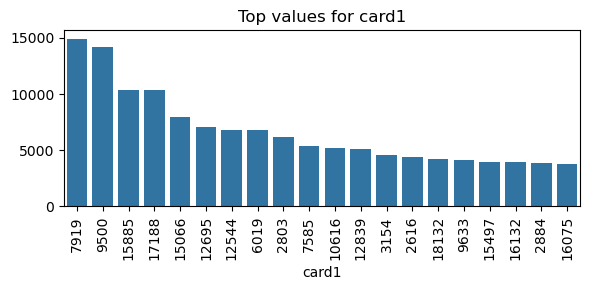

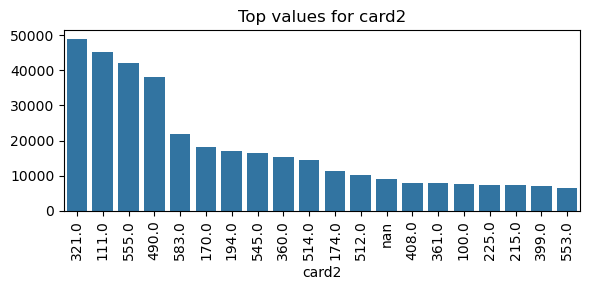

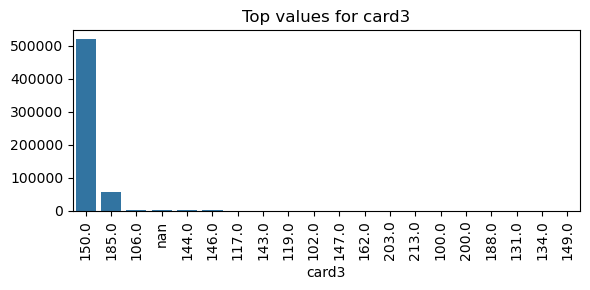

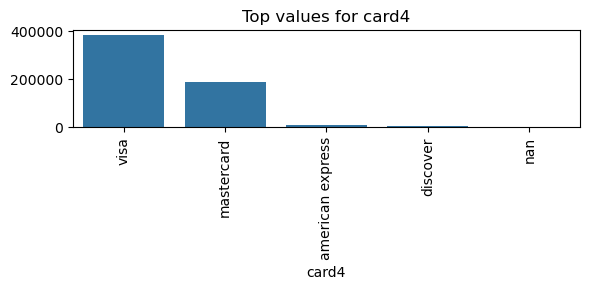

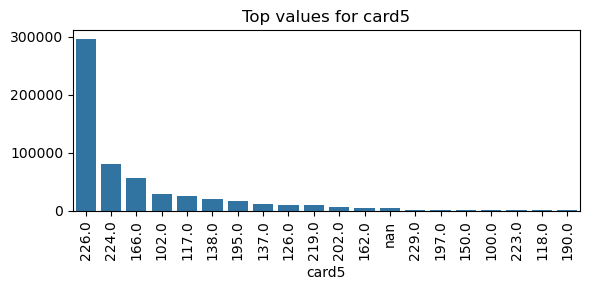

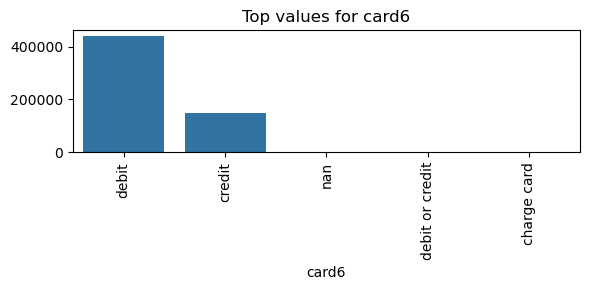

In [9]:
card_cols = [c for c in train_trans.columns if c.startswith('card')]
card_cols

for c in card_cols:
    plt.figure(figsize=(6,3))
    value_counts = train[c].value_counts(dropna=False).head(20)
    sns.barplot(x=value_counts.index.astype(str), y=value_counts.values)
    plt.xticks(rotation=90)
    plt.title(f"Top values for {c}")
    plt.tight_layout()
    plt.savefig(f"images/TopValuesFor-{c}.png")
    plt.show()

### 4.3 Address and email ###

['addr1', 'addr2']


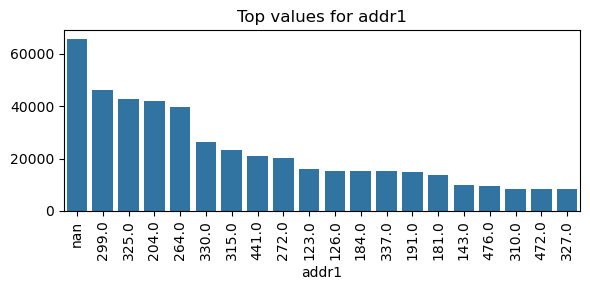

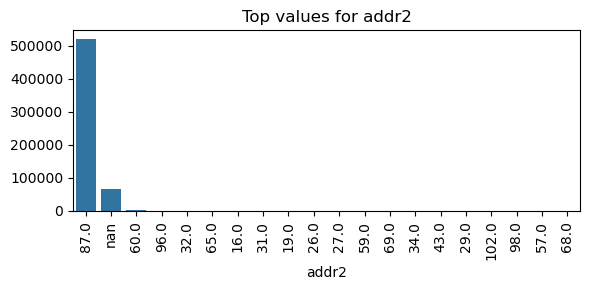

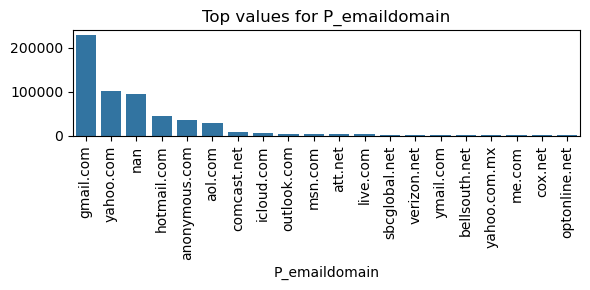

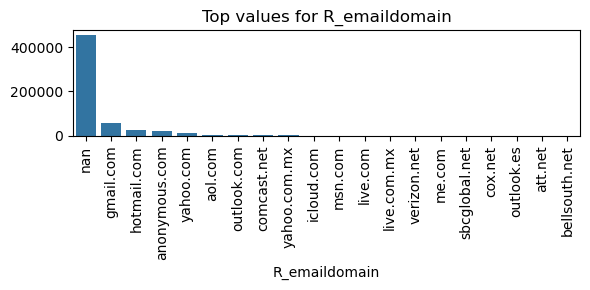

In [10]:
addr_cols = [c for c in train_trans.columns if c.startswith('addr')]
print(addr_cols)

for c in addr_cols + ['P_emaildomain', 'R_emaildomain']:
    if c in train.columns:
        vc = train[c].value_counts(dropna=False).head(20)
        plt.figure(figsize=(6,3))
        sns.barplot(x=vc.index.astype(str), y=vc.values)
        plt.xticks(rotation=90)
        plt.title(f"Top values for {c}")
        plt.tight_layout()
        plt.savefig(f"images/TopValuesFor-{c}.png")
        plt.show()

### 4.4 Identity / device features ###

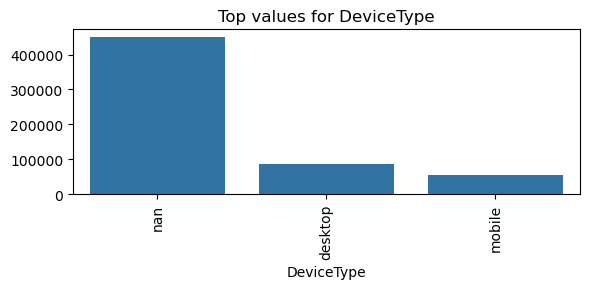

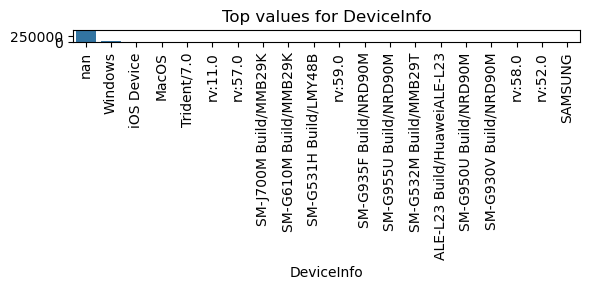

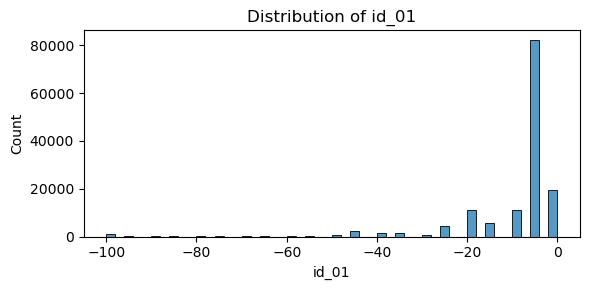

In [11]:
id_cols = train_id.columns.drop(['TransactionID']) if 'TransactionID' in train_id.columns else train_id.columns

# Example: DeviceType, DeviceInfo, id_01
for c in ['DeviceType', 'DeviceInfo', 'id_01']:
    if c in train.columns:
        if train[c].dtype == 'O':
            vc = train[c].value_counts(dropna=False).head(20)
            plt.figure(figsize=(6,3))
            sns.barplot(x=vc.index.astype(str), y=vc.values)
            plt.xticks(rotation=90)
            plt.title(f"Top values for {c}")
            plt.tight_layout()
            plt.savefig(f"images/TopValuesFor-{c}.png")
            plt.show()
        else:
            plt.figure(figsize=(6,3))
            sns.histplot(train[c], bins=50, kde=False)
            plt.title(f"Distribution of {c}")
            plt.tight_layout()
            plt.savefig(f"images/DistributionOf-{c}.png")
            plt.show()

## 5. EDA: Fraud vs non‑fraud comparisons (bivariate) ##
Now I compare distributions conditioned on isFraud to spot discriminative patterns.

### 5.1 Transaction amount by fraud label ###

For more stable plots, use log1p:

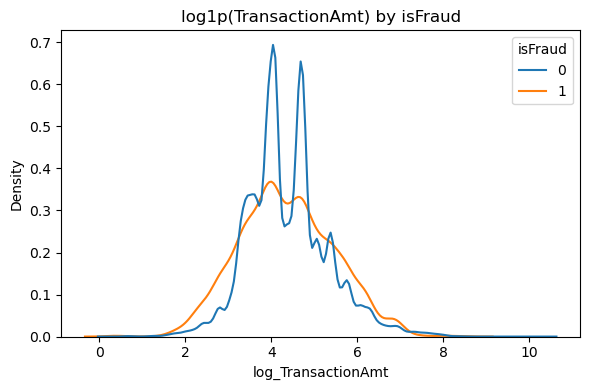

In [12]:
sample = train.sample(150000, random_state=42)
sample['log_TransactionAmt'] = np.log1p(sample['TransactionAmt'])

plt.figure(figsize=(6,4))
sns.kdeplot(
    data=sample,
    x='log_TransactionAmt',
    hue='isFraud',
    common_norm=False
)
plt.title("log1p(TransactionAmt) by isFraud")
plt.tight_layout()
plt.savefig("images/log1pTransactionAmtBy_isFraud.png")
plt.show()

## 5.2 Fraud rate by card and email domains ##

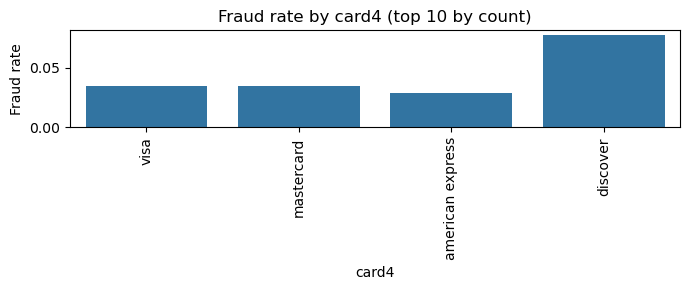

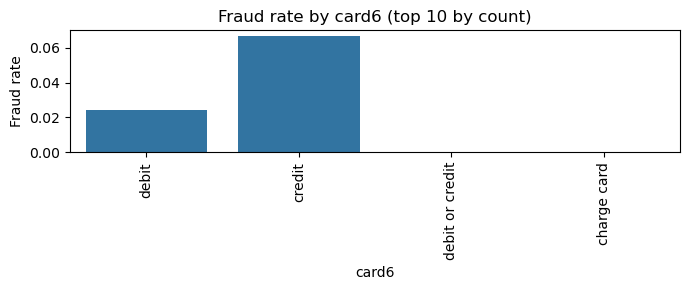

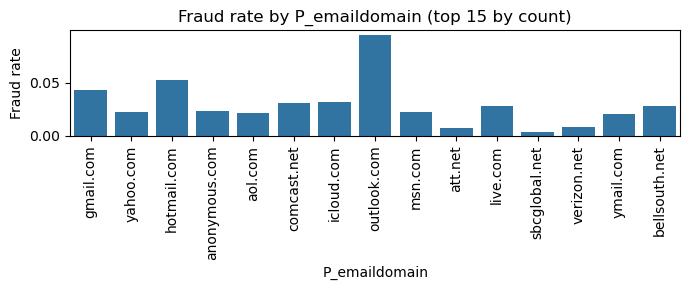

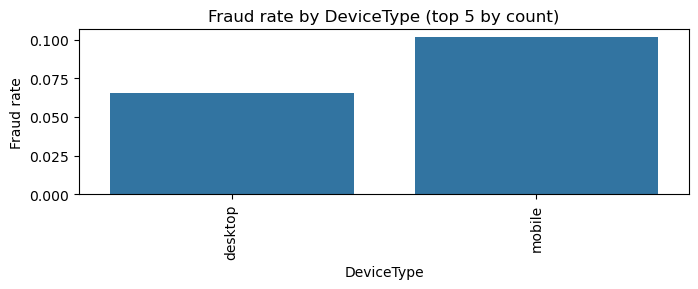

,DeviceType,mean,count
0,desktop,0.065215,85165
1,mobile,0.101662,55645


In [13]:
def fraud_rate_by_feature(df, feature, top_n=10):
    tmp = df.groupby(feature)['isFraud'].agg(['mean', 'count']).sort_values('count', ascending=False).head(top_n)
    tmp = tmp.reset_index()
    plt.figure(figsize=(7,3))
    sns.barplot(data=tmp, x=feature, y='mean')
    plt.xticks(rotation=90)
    plt.ylabel('Fraud rate')
    plt.title(f"Fraud rate by {feature} (top {top_n} by count)")
    plt.tight_layout()
    plt.savefig(f"images/FraudRateBy_{feature}_(top_{top_n}_ByCount).png")
    plt.show()
    return tmp

fraud_rate_by_feature(train, 'card4', top_n=10)
fraud_rate_by_feature(train, 'card6', top_n=10)
fraud_rate_by_feature(train, 'P_emaildomain', top_n=15)
fraud_rate_by_feature(train, 'DeviceType', top_n=5)

## 5.3 Time‑based patterns ##
Convert TransactionDT to approximate day and hour and examine fraud rate across these.

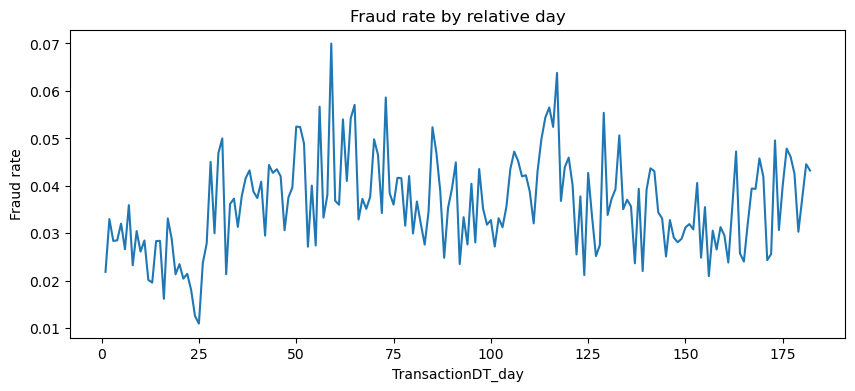

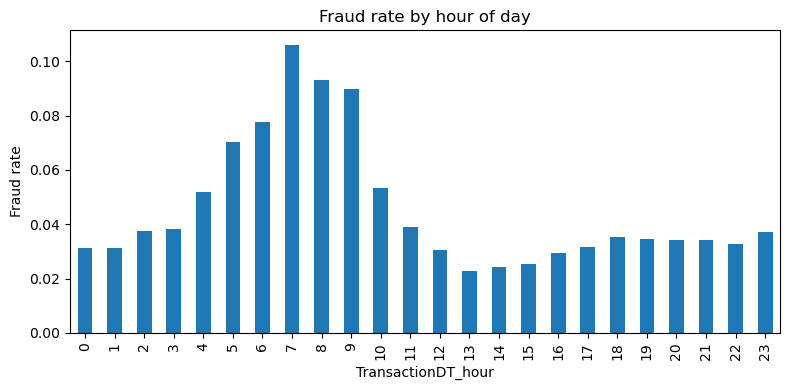

In [14]:
# Make sure we don't re-create columns if they already exist
if 'TransactionDT_day' not in train.columns:
    train['TransactionDT_days'] = train['TransactionDT'] / (24*60*60)
    train['TransactionDT_day'] = train['TransactionDT_days'].astype(int)
    train['TransactionDT_hour'] = (train['TransactionDT'] // 3600) % 24

# Fraud rate by day
day_stats = train.groupby('TransactionDT_day')['isFraud'].agg(['mean','count'])

plt.figure(figsize=(10,4))
day_stats['mean'].plot()
plt.title("Fraud rate by relative day")
plt.ylabel("Fraud rate")
plt.show()

# Fraud rate by hour of day
hour_stats = train.groupby('TransactionDT_hour')['isFraud'].agg(['mean','count'])

plt.figure(figsize=(8,4))
hour_stats['mean'].plot(kind='bar')
plt.title("Fraud rate by hour of day")
plt.ylabel("Fraud rate")
plt.tight_layout()
plt.savefig("images/FraudRateByHourOfDay.png")
plt.show()

## 5.4  Fraud rate by categorical features ##

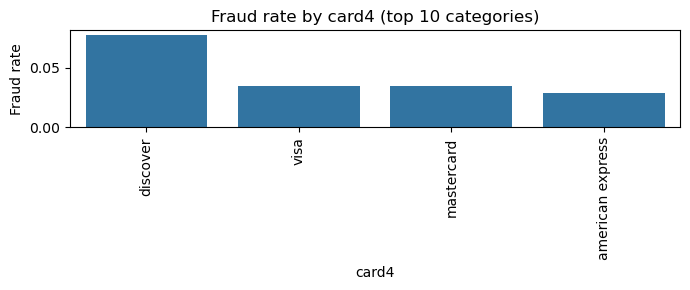

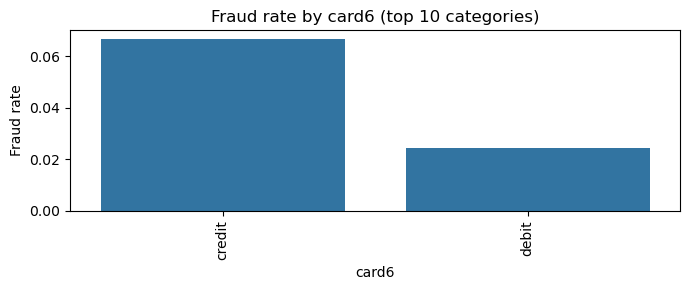

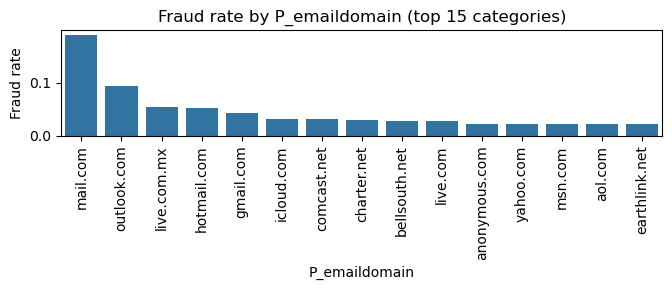

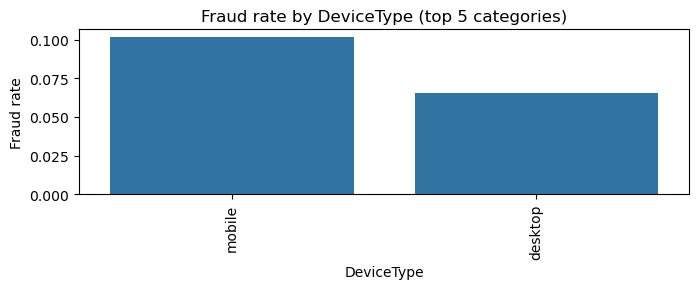

In [15]:
def fraud_rate_table(df, feature, min_count=200):
    # Group by feature and compute fraud rate + count
    tmp = df.groupby(feature)['isFraud'].agg(['mean','count'])
    tmp = tmp[tmp['count'] >= min_count].sort_values('mean', ascending=False)
    return tmp

def plot_fraud_rate_bar(df, feature, top_n=10, min_count=200):
    tmp = fraud_rate_table(df, feature, min_count=min_count).head(top_n)
    if tmp.empty:
        print(f"No categories with count >= {min_count} for {feature}")
        return tmp
    plt.figure(figsize=(7,3))
    sns.barplot(x=tmp.index.astype(str), y=tmp['mean'])
    plt.xticks(rotation=90)
    plt.ylabel('Fraud rate')
    plt.title(f"Fraud rate by {feature} (top {top_n} categories)")
    plt.tight_layout()
    plt.savefig(f"images/FraudRateBy_{feature}_(top_{top_n}_categories).png")
    plt.show()
    return tmp

# Examples
card4_fr = plot_fraud_rate_bar(train, 'card4', top_n=10, min_count=500)
card6_fr = plot_fraud_rate_bar(train, 'card6', top_n=10, min_count=500)
p_email_fr = plot_fraud_rate_bar(train, 'P_emaildomain', top_n=15, min_count=500)
device_fr  = plot_fraud_rate_bar(train, 'DeviceType', top_n=5, min_count=500)

In [16]:
# Save these
card4_fr.to_csv("intermediate_output/fraud_rate_card4.csv")
p_email_fr.to_csv("intermediate_output/fraud_rate_P_emaildomain.csv")

### Numerical "D" and "C" features vs fraud.
These often capture delays and counts; some may be strong predictors
I verify these to see which show clear separation

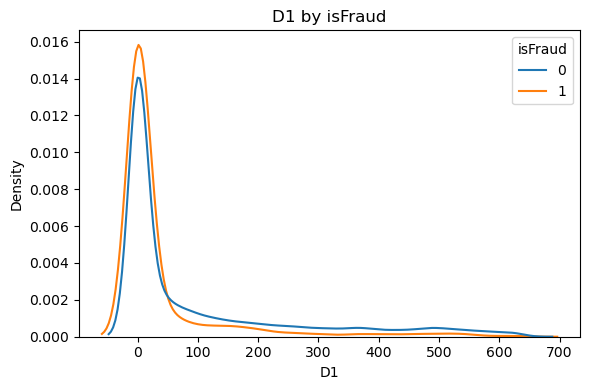

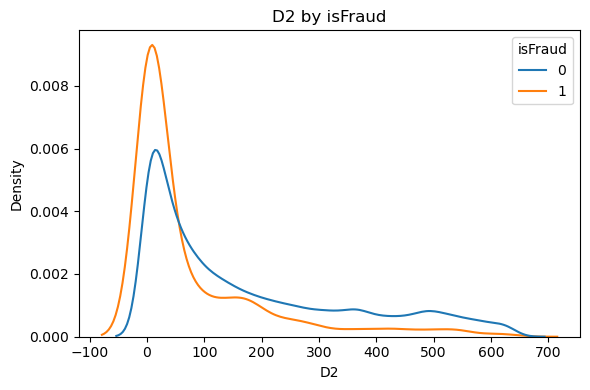

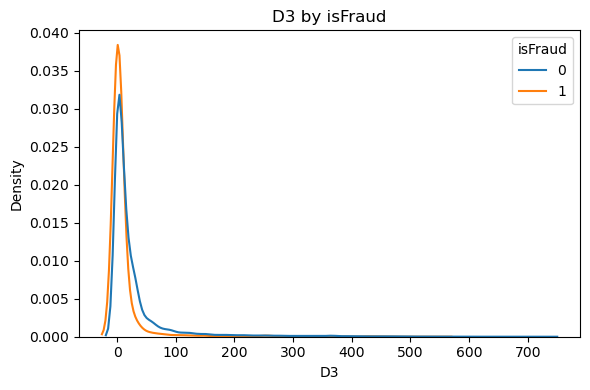

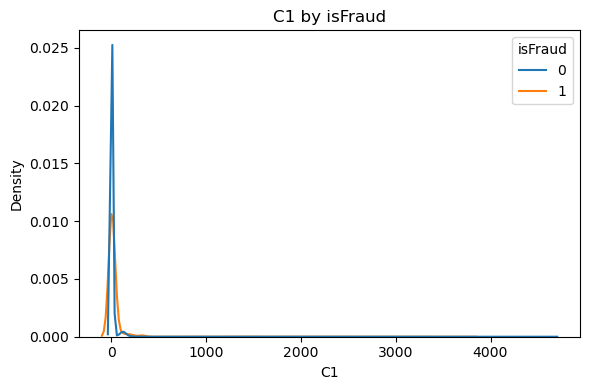

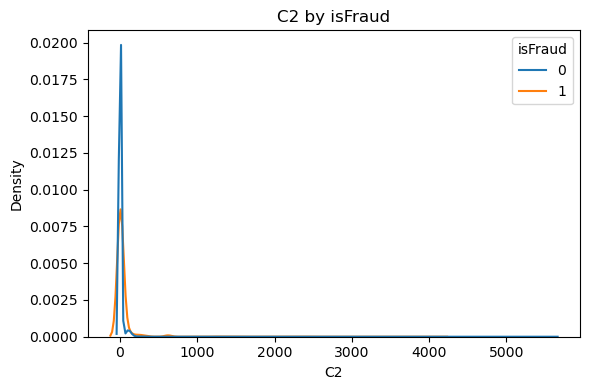

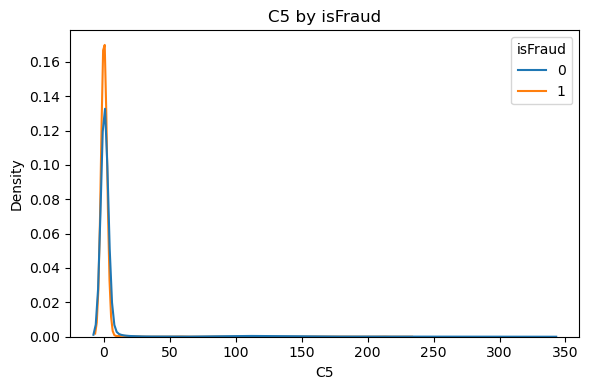

In [17]:
num_for_kde = ['D1', 'D2', 'D3', 'C1', 'C2', 'C5']
for col in num_for_kde:
    if col in train.columns:
        plt.figure(figsize=(6,4))
        sns.kdeplot(
            data=train[~train[col].isnull()].sample(100000, random_state=42),
            x=col,
            hue='isFraud',
            common_norm=False
        )
        plt.title(f"{col} by isFraud")
        plt.tight_layout()
        plt.savefig(f"images/{col}_By_isFraud.png")
        plt.show()

## 6. EDA: Behaviour‑style / velocity  ##
Here I start to approximate the behavioural ideas I described (velocity, deviations) but still treat them as EDA, not final features.

Example: transaction count per card over a time window.

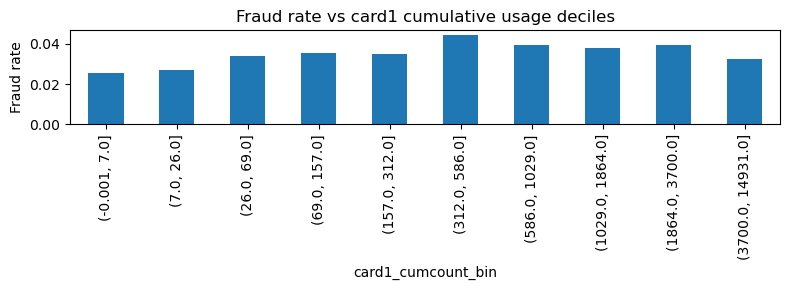

In [18]:
df_beh = train[['TransactionID', 'TransactionDT', 'isFraud', 'card1', 'TransactionAmt']].copy()
df_beh = df_beh.sort_values(['card1', 'TransactionDT'])

# Cumulative count per card (proxy for experience / usage)
df_beh['card1_cumcount'] = df_beh.groupby('card1').cumcount()

# Bucket into deciles
df_beh['card1_cumcount_bin'] = pd.qcut(df_beh['card1_cumcount'], 10, duplicates='drop')

fraud_by_cumcount = df_beh.groupby('card1_cumcount_bin', observed=True)['isFraud'].mean()

plt.figure(figsize=(8,3))
fraud_by_cumcount.plot(kind='bar')
plt.title("Fraud rate vs card1 cumulative usage deciles")
plt.ylabel("Fraud rate")
plt.tight_layout()
plt.savefig("images/FraudRateVsCard1_CumulativeUsageDeciles.png")
plt.show()

Also check average amount per card and deviations. This shows whether fraud tends to be unusually high/low relative to a card’s baseline.

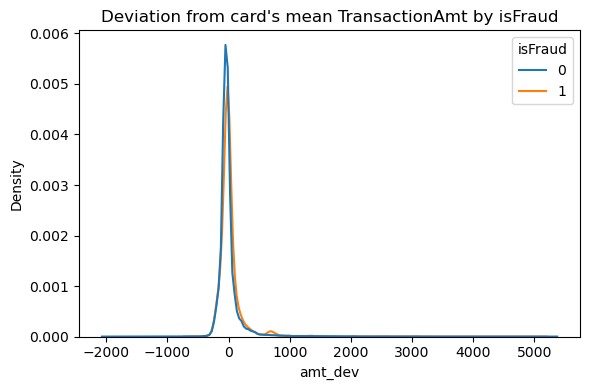

In [19]:
df_beh['card1_mean_amt'] = df_beh.groupby('card1')['TransactionAmt'].transform('mean')
df_beh['amt_dev'] = df_beh['TransactionAmt'] - df_beh['card1_mean_amt']

sample_beh = df_beh.sample(150000, random_state=42)

plt.figure(figsize=(6,4))
sns.kdeplot(
    data=sample_beh,
    x='amt_dev',
    hue='isFraud',
    common_norm=False
)
plt.title("Deviation from card's mean TransactionAmt by isFraud")
plt.tight_layout()
plt.savefig("images/DeviationFromCardMeanTransactionAmt_By_isFraud.png")
plt.show()

## 7. EDA: Class imbalance inspection ##
I already looked at the target proportion; now I check how this affects metrics later and where fraud sits in feature space.

A quick PCA view on a subset of numeric features for intuition. This helps see whether fraud is linearly separable or heavily overlapping in the chosen projection.

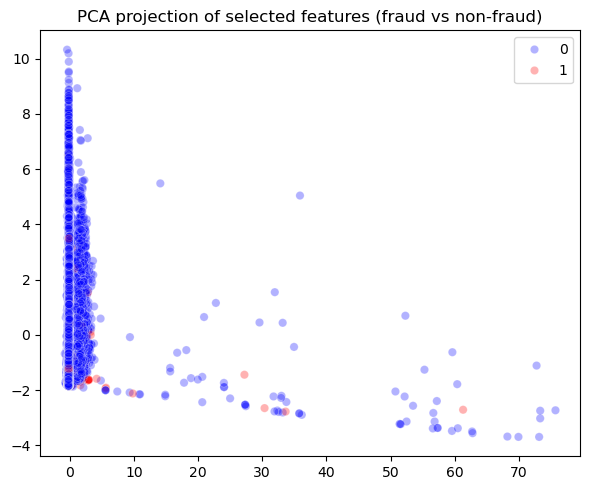

In [20]:
# Use a small numeric subset (e.g., TransactionAmt, D1-D5, C1-C5)
subset_cols = ['TransactionAmt'] + [c for c in train.columns if c.startswith('D')][:5] + [c for c in train.columns if c.startswith('C')][:5]
subset_cols = [c for c in subset_cols if c in train.columns]

sample = train[subset_cols + ['isFraud']].dropna().sample(50000, random_state=42)

X = sample[subset_cols].values
y = sample['isFraud'].values

X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, alpha=0.3, palette={0:'blue',1:'red'})
plt.title("PCA projection of selected features (fraud vs non-fraud)")
plt.tight_layout()
plt.savefig("images/PCAProjectionOfSelectedFeatures_(fraud_vs_non-fraud).png")
plt.show()

**The graph clearly indicates that there is overlap**

## 8 EDA: Correlation heatmaps ##
because IEEE‑CIS has 400+ features, I have to be selective, otherwise the heatmap becomes unreadable and slow to compute.

### 8.1 General Correlation heatmap helper ###

In [21]:
def plot_corr_heatmap(corr, title="Correlation matrix", vmax=0.3):
    mask = np.triu(np.ones_like(corr, dtype=bool))
    f, ax = plt.subplots(figsize=(11, 9))
    cmap = sns.diverging_palette(230, 20, as_cmap=True)

    sns.heatmap(
        corr,
        mask=mask,
        cmap=cmap,
        vmax=vmax,
        center=0,
        square=True,
        linewidths=.5,
        cbar_kws={"shrink": .5}
    )
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f"images/{title}.png")
    plt.show()

### 8.2 Correlation for a focused subset of numeric features ###

Subset columns for correlation: ['TransactionAmt', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'id_01', 'id_02', 'id_03', 'id_04']


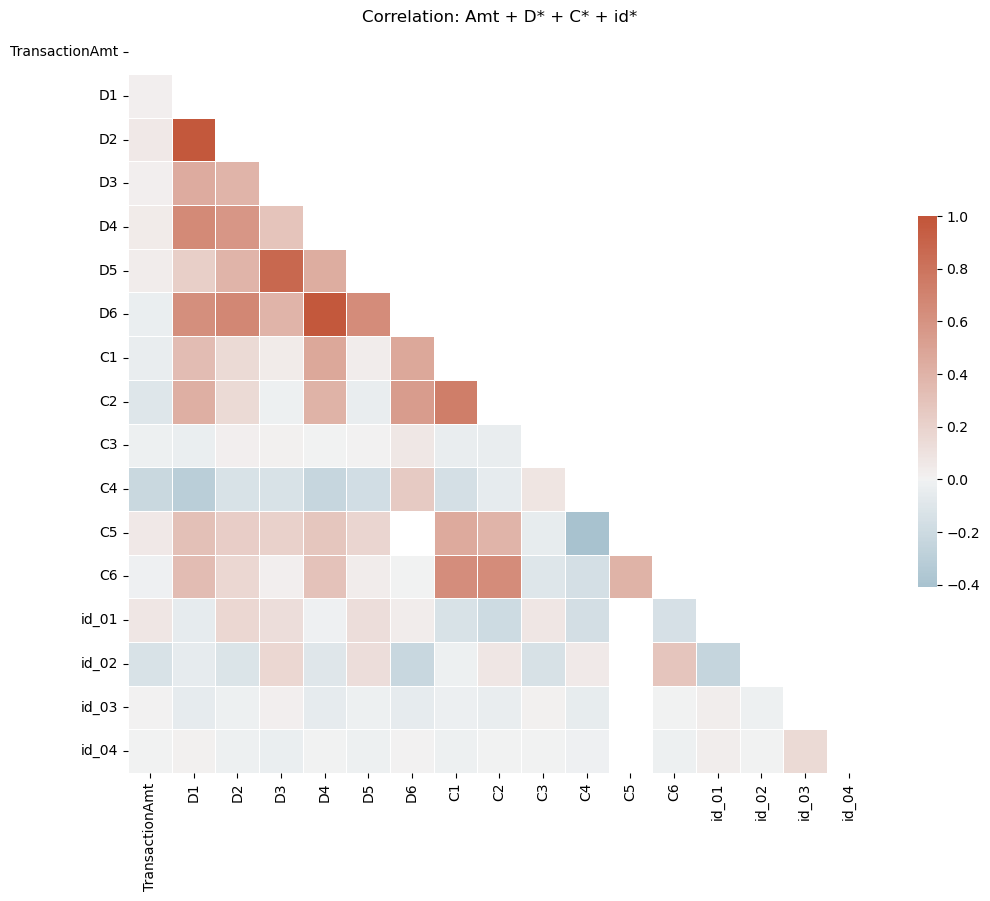

In [22]:
# Choose a small numeric subset
subset_cols = ['TransactionAmt']

subset_cols += [c for c in train.columns if c.startswith('D')][:6]   # D1-D6
subset_cols += [c for c in train.columns if c.startswith('C')][:6]   # C1-C6
subset_cols += [c for c in train.columns if c.startswith('id_')][:4] # id_01-id_04

subset_cols = list(dict.fromkeys([c for c in subset_cols if c in train.columns]))  # unique, existing

print("Subset columns for correlation:", subset_cols)

# Drop rows with all-NaN in these columns
corr_df = train[subset_cols].dropna(how='all')

corr = corr_df.corr(method='spearman')
plot_corr_heatmap(corr, title="Correlation: Amt + D* + C* + id*", vmax=1.0)

### 8.3 Block wise correlation for V-features (and how to use it to drop redundant ones) ###
The V‑features are many and often highly correlated. A common approach is:
- Work on them in blocks (e.g. V1–V50, V51–V100) to keep heatmaps readable.
- For each block, calculate correlations and identify groups of highly correlated features (e.g. |ρ| > 0.9).
- Later, keep only one feature per highly‑correlated group to reduce redundancy.

V-block 1-50: 50 columns


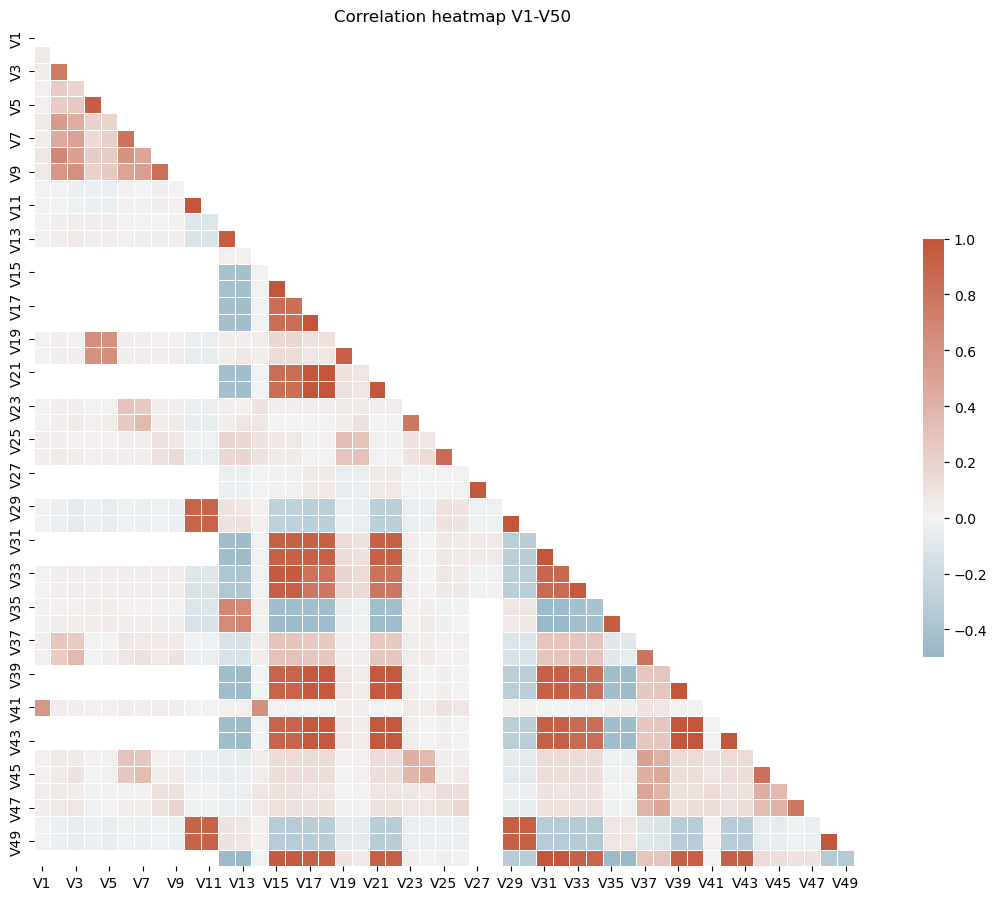

In [23]:
# 1) Plot heatmap for a block
def plot_v_block_corr(train, start=1, end=50):
    v_cols = [f"V{i}" for i in range(start, end+1) if f"V{i}" in train.columns]
    print(f"V-block {start}-{end}: {len(v_cols)} columns")
    if not v_cols:
        return None

    # Sample rows for speed
    sample = train[v_cols].sample(50000, random_state=42)
    corr = sample.corr(method='spearman')
    plot_corr_heatmap(corr, title=f"Correlation heatmap V{start}-V{end}", vmax=1.0)
    return corr

corr_v1_50 = plot_v_block_corr(train, 1, 50)
#  explore others later:
# corr_v51_100 = plot_v_block_corr(train, 51, 100)

In [24]:
# 2) Identify highly correlated V‑feature groups
#This is useful for feature reduction later
def find_high_corr_groups(corr, threshold=0.9):
    # corr is a DataFrame of correlations for one block of features
    cols = corr.columns
    visited = set()
    groups = []

    for col in cols:
        if col in visited:
            continue
        # Find features strongly correlated with this one
        high_corr = corr.index[corr[col].abs() > threshold].tolist()
        if len(high_corr) > 1:
            groups.append(high_corr)
            visited.update(high_corr)
        else:
            visited.add(col)

    return groups

# Example on the V1-50 block
if corr_v1_50 is not None:
    v_groups = find_high_corr_groups(corr_v1_50, threshold=0.9)
    print(f"Found {len(v_groups)} highly correlated groups in V1-50")
    for g in v_groups[:5]:
        print(g)

Found 8 highly correlated groups in V1-50
['V4', 'V5']
['V10', 'V11', 'V29', 'V30', 'V48', 'V49']
['V12', 'V13']
['V15', 'V16', 'V31', 'V32', 'V33', 'V34', 'V50']
['V17', 'V18', 'V21', 'V22', 'V31', 'V32', 'V39', 'V40', 'V42', 'V43', 'V50']


### 8.4 Correlation with the target( isFraud) for feature screening
Rather than only feature–feature correlation, it is helpful to see which numeric variables correlate most (even weakly) with isFraud
This gives a ranked list I can reference in the report: e.g., “D1, Vxxx, and C1 showed the strongest (though still modest) correlation with the fraud label.”

Top 20 positively correlated with isFraud:
V244    0.404460
V246    0.398693
V242    0.395531
V243    0.389075
V257    0.387434
V258    0.385553
V187    0.356946
V190    0.351649
V199    0.343503
V186    0.342284
V232    0.316612
V274    0.313596
V233    0.311725
V275    0.308356
V231    0.299720
V273    0.296365
V230    0.286948
V201    0.282981
V229    0.281454
V219    0.276900
Name: isFraud, dtype: float64

Top 20 negatively correlated with isFraud:
V35     -0.078724
D15     -0.080501
D10     -0.086074
C9      -0.093484
id_07   -0.096066
C5      -0.105389
V69     -0.108287
V70     -0.108398
V30     -0.110511
V29     -0.111120
D2      -0.111185
V91     -0.113830
V90     -0.114159
V49     -0.118202
D3      -0.118305
V48     -0.118977
id_01   -0.121786
D5      -0.165162
D8      -0.196630
D7      -0.198858
Name: isFraud, dtype: float64


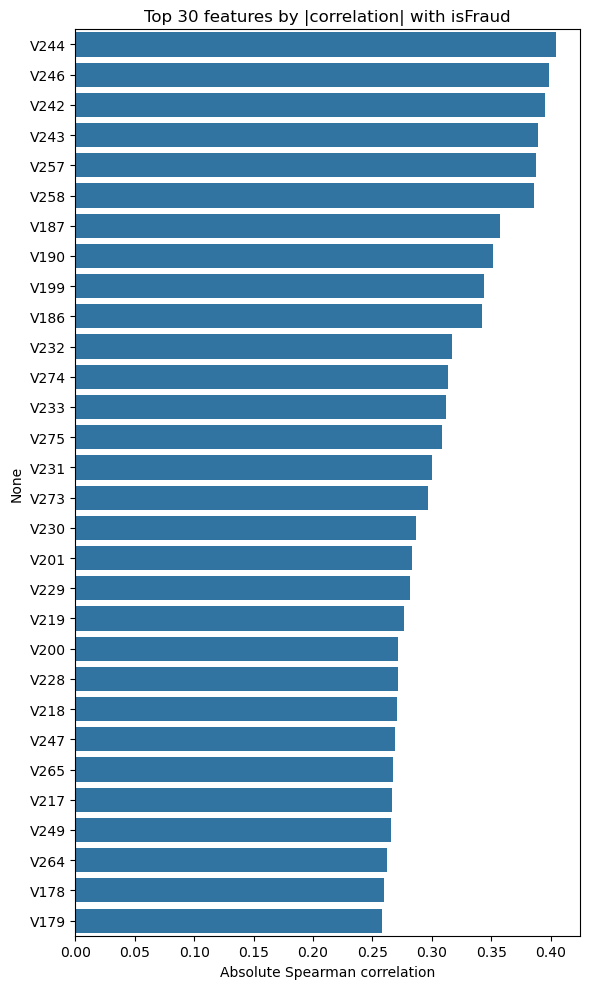

In [25]:
# Compute correlation of numeric features with isFraud
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'isFraud']

corr_target = train[numeric_cols + ['isFraud']].corr(method='spearman')['isFraud'].drop('isFraud')
corr_target = corr_target.sort_values(ascending=False)

print("Top 20 positively correlated with isFraud:")
print(corr_target.head(20))

print("\nTop 20 negatively correlated with isFraud:")
print(corr_target.tail(20))

# Plot the top 30 by absolute correlation
top_n = 30
top_abs = corr_target.abs().sort_values(ascending=False).head(top_n)

plt.figure(figsize=(6,10))
sns.barplot(x=top_abs.values, y=top_abs.index)
plt.title(f"Top {top_n} features by |correlation| with isFraud")
plt.xlabel("Absolute Spearman correlation")
plt.tight_layout()
plt.savefig(f"images/Top_{top_n}_FeaturesBy_correlation_with_isFraud.png")
plt.show()

## 9 EDA: Summary fo Key Findings ##
**Data structure**
-  I merged train_transaction (590,540 × 394) and train_identity (144,233 × 41) into a 590,540 × 434 training table and similarly merged the test tables.
-  The target isFraud has mean ≈ 0.035, confirming ~3.5% fraud rate (strong class imbalance).

**Core numeric features**
- TransactionAmt is positive, clearly right‑skewed with a heavy tail; the median is ~68.8 and the maximum is ~31,937, indicating a few very large outliers.
- TransactionDT spans a large range and is not a calendar timestamp but an increasing integer that one can convert to approximate days and hours; distributions are broad, as expected.
- Customer‑behaviour count features C1–C8 show extreme skew: medians at 0–1 with occasional large values (thousands), consistent with count‑style features that can be good predictors.

**Categorical / identity hints**
- DeviceType appears in the merged table with non‑trivial missingness and different fraud rates: in your small table desktop has ~6.5% and mobile ~10.2% fraud (on the subset shown), suggesting device type is informative.
- The identity file contributes 41 additional fields (id_01–id_38, DeviceType, DeviceInfo) but many have high missing fractions and need careful treatment.

**Missingness**
- Many identity and V‑features have substantial missingness (often > 50%, some > 90%), while core transaction fields like TransactionAmt, card1, C1–C8 are largely complete.
- This pattern suggests a two‑tier feature set: robust, low‑missing transaction features and sparser identity/V‑features to be either imputed or selectively used.

## 10. Data Preprocessing and Feature pipeline design ##
The idea is to:
- Drop clearly unhelpful or extremely sparse features
- Create interpretable time and log-amount features
- Encode categoricals (target counts = frequency) in a simple, leakage-safe way
- - Impute numeric and categorical values
  - Standardise numeric features for Logistic Regression

### 10.1 Define Feature groups ###

In [26]:
TARGET = 'isFraud'

# Identify dtypes
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = train.select_dtypes(exclude=[np.number]).columns.tolist()

num_cols = [c for c in num_cols if c != TARGET]

print("Numeric cols:", len(num_cols))
print("Categorical cols:", len(cat_cols))

Numeric cols: 405
Categorical cols: 31


### 10.2 Mark high-missing and ID-like features to drop ###

In [27]:
missing_train = train.isnull().mean()

# Drop threshold: > 95% missing
high_missing = missing_train[missing_train > 0.95].index.tolist()

# ID-like or non-informative columns
id_like = ['TransactionID']  # extend list if needed

drop_cols = set(high_missing + id_like)

print("High-missing (>95%) features:", len(high_missing))
print("Drop columns (initial):", len(drop_cols))

High-missing (>95%) features: 9
Drop columns (initial): 10


### 10.3 Create engineered features (amount & time & simple risk) ###

In [28]:
def add_basic_features(df):
    df = df.copy()
    # Log amount
    df['log_TransactionAmt'] = np.log1p(df['TransactionAmt'])
    
    # Time features
    df['TransactionDT_days'] = df['TransactionDT'] / (24*60*60)
    df['TransactionDT_day'] = df['TransactionDT_days'].astype(int)
    df['TransactionDT_hour'] = (df['TransactionDT'] // 3600) % 24
    df['is_weekend'] = df['TransactionDT_day'] % 7 >= 5
    
    return df

train_fe = add_basic_features(train)

In [29]:
# add simple count/risk encodings for selected categorical features:

risk_cols = ['card1', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'DeviceType']

def add_count_and_risk_features(df, target_col=TARGET):
    df = df.copy()
    for col in risk_cols:
        if col in df.columns:
            vc = df[col].value_counts()
            df[f'{col}_count'] = df[col].map(vc)
            
            # Fraud rate (avoid leakage in a real setting: here we use full train just for simplicity)
            fr = df.groupby(col)[target_col].mean()
            df[f'{col}_fraud_rate'] = df[col].map(fr)
    return df

train_fe = add_count_and_risk_features(train_fe)

### 10.4 Final feature list for Logistic Regression baseline ###
For a first baseline, I keep a reasonably small, robust feature set:
- Core numeric: TransactionAmt, log_TransactionAmt, C1–C8, first few D*, maybe addr1, dist1.
- Engineered time: TransactionDT_day, TransactionDT_hour, is_weekend.
- Count/risk: the *_count and *_fraud_rate created above.

In [30]:
# Core numeric candidates
core_num = [
    'TransactionAmt', 'log_TransactionAmt',
    'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8',
    'D1', 'D2', 'D3', 'D4', 'D5',
    'addr1', 'dist1',
    'TransactionDT_day', 'TransactionDT_hour'
]

core_num = [c for c in core_num if c in train_fe.columns]

# Engineered risk/count features
eng_features = []
for col in risk_cols:
    for suffix in ['_count', '_fraud_rate']:
        f = f'{col}{suffix}'
        if f in train_fe.columns:
            eng_features.append(f)

# Boolean to numeric
bool_cols = ['is_weekend']
bool_cols = [c for c in bool_cols if c in train_fe.columns]

feature_cols = core_num + eng_features + bool_cols
feature_cols = [c for c in feature_cols if c not in drop_cols]

print("Number of features selected:", len(feature_cols))
feature_cols

Number of features selected: 32


['TransactionAmt',
 'log_TransactionAmt',
 'C1',
 'C2',
 'C3',
 'C4',
 'C5',
 'C6',
 'C7',
 'C8',
 'D1',
 'D2',
 'D3',
 'D4',
 'D5',
 'addr1',
 'dist1',
 'TransactionDT_day',
 'TransactionDT_hour',
 'card1_count',
 'card1_fraud_rate',
 'card4_count',
 'card4_fraud_rate',
 'card6_count',
 'card6_fraud_rate',
 'P_emaildomain_count',
 'P_emaildomain_fraud_rate',
 'R_emaildomain_count',
 'R_emaildomain_fraud_rate',
 'DeviceType_count',
 'DeviceType_fraud_rate',
 'is_weekend']

### 10.5 Imputation & Scaling ###
- Numeric: median imputation + standard scaling.
- Count/risk features are numeric too, so they fall into the same pipeline.
WI will use ColumnTransformer + Pipeline.

In [31]:
X = train_fe[feature_cols]
y = train_fe[TARGET]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_features = feature_cols  # all selected features are numeric here

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features)
    ]
)

## 11 Baseline Logistic Regression (L1/L2) ##
We’ll try both L2 (default) and L1 with class weighting to account for imbalance, and evaluate using ROC‑AUC and PR‑AUC on the validation set.

### 11.1 L2-regularised Logistic Regression baseline ###

In [32]:
# L2-regularised Logistic Regression baseline
logreg_l2 = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        penalty="l2",
        C=1.0,
        class_weight="balanced",
        max_iter=1000,
        solver="lbfgs"
    ))
])

logreg_l2.fit(X_train, y_train)

y_valid_proba_l2 = logreg_l2.predict_proba(X_valid)[:, 1]
y_valid_pred_l2 = (y_valid_proba_l2 >= 0.5).astype(int)

roc_l2 = roc_auc_score(y_valid, y_valid_proba_l2)
pr_l2 = average_precision_score(y_valid, y_valid_proba_l2)

print("L2 Logistic Regression:")
print(f"ROC-AUC: {roc_l2:.4f}")
print(f"PR-AUC:  {pr_l2:.4f}")
print("\nConfusion matrix (threshold=0.5):")
print(confusion_matrix(y_valid, y_valid_pred_l2))
print("\nClassification report:")
print(classification_report(y_valid, y_valid_pred_l2, digits=4))

L2 Logistic Regression:
ROC-AUC: 0.8612
PR-AUC:  0.3162

Confusion matrix (threshold=0.5):
[[95763 18212]
 [ 1166  2967]]

Classification report:
              precision    recall  f1-score   support

           0     0.9880    0.8402    0.9081    113975
           1     0.1401    0.7179    0.2344      4133

    accuracy                         0.8359    118108
   macro avg     0.5640    0.7790    0.5713    118108
weighted avg     0.9583    0.8359    0.8845    118108



### 11.2 L1-regularised Logistic Regression with more iterations and stronger regularisation ###

In [33]:
# L1-regularised Logistic Regression with more iterations and stronger regularisation
logreg_l1 = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        penalty="l1",
        C=0.2,                 # stronger regularisation than 0.5
        class_weight="balanced",
        max_iter=3000,         # more iterations to help convergence
        solver="saga",
        tol=1e-3,              # slightly looser tolerance to converge faster
        n_jobs=-1
    ))
])

logreg_l1.fit(X_train, y_train)

y_valid_proba_l1 = logreg_l1.predict_proba(X_valid)[:, 1]
y_valid_pred_l1 = (y_valid_proba_l1 >= 0.5).astype(int)

roc_l1 = roc_auc_score(y_valid, y_valid_proba_l1)
pr_l1 = average_precision_score(y_valid, y_valid_proba_l1)

print("L1 Logistic Regression (tuned for convergence):")
print(f"ROC-AUC: {roc_l1:.4f}")
print(f"PR-AUC:  {pr_l1:.4f}")
print("\nConfusion matrix (threshold=0.5):")
print(confusion_matrix(y_valid, y_valid_pred_l1))
print("\nClassification report:")
print(classification_report(y_valid, y_valid_pred_l1, digits=4))

L1 Logistic Regression (tuned for convergence):
ROC-AUC: 0.8612
PR-AUC:  0.3146

Confusion matrix (threshold=0.5):
[[95746 18229]
 [ 1171  2962]]

Classification report:
              precision    recall  f1-score   support

           0     0.9879    0.8401    0.9080    113975
           1     0.1398    0.7167    0.2339      4133

    accuracy                         0.8357    118108
   macro avg     0.5638    0.7784    0.5710    118108
weighted avg     0.9582    0.8357    0.8844    118108



**REMARKS**

Baseline model: Logistic Regression
For an initial baseline, I trained regularised Logistic Regression models using the engineered feature set described in the previous section (log‑transformed transaction amount, time‑based features, customer behaviour counts C1–C8, early delay features D1–D5, location features addr1/dist1, and simple count and fraud‑rate encodings for card, email domain, and device type). Median imputation and standardisation were applied to all numeric features, and features with more than 95% missing values or purely identifier roles (e.g. TransactionID) were excluded from the model input. Class imbalance (only 3.5% of training transactions are labelled as fraud) was handled using class‑weighted loss during training.

Both an L2‑ and an L1‑regularised Logistic Regression were fitted on an 80/20 stratified train–validation split. The L2 model achieved a ROC‑AUC of 0.8612 and a PR‑AUC of 0.3162 on the validation set, while the L1 model reached a ROC‑AUC of 0.8612 and a PR‑AUC of 0.3146. Given a baseline fraud prevalence of about 3.5%, these PR‑AUC scores represent a substantial improvement over random guessing, indicating that even a linear model can learn meaningful structure in the data.

At the default decision threshold of 0.5, the L2 Logistic Regression achieves 71.8% recall and 14.0% precision on the fraud class, with a confusion matrix of [[95,763, 18,212], [1,166, 2,967]] (non‑fraud negative/positive; fraud negative/positive). In practical terms, the model correctly flags roughly seven out of ten fraudulent transactions but at the cost of a high false alarm rate: about six out of seven flagged transactions are legitimate. Overall accuracy is 83.6%, but this figure is less meaningful due to the strong class imbalance. The L1‑regularised model displays almost identical behaviour (ROC‑AUC 0.8612, PR‑AUC 0.3146, fraud recall 71.7% and precision 14.0%), but with a sparser set of non‑zero coefficients, making it somewhat easier to inspect individual feature weights.

These results demonstrate that the current preprocessing and feature engineering pipeline is sound and that even a simple linear classifier can distinguish fraud from legitimate transactions substantially better than chance. However, the precision–recall trade‑off at the 0.5 threshold is not yet suitable for deployment in a real‑time fraud system, where the cost of false positives must be balanced carefully against the cost of missed fraud. Subsequent work therefore focuses on exploring more expressive model families (e.g., gradient‑boosted trees) and on explicitly optimising the operating threshold and cost‑sensitive metrics to better align with business requirements.

### 11.3 PR / ROC curves and threshold analysis ###

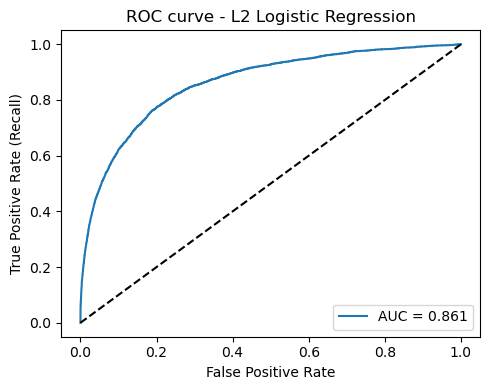

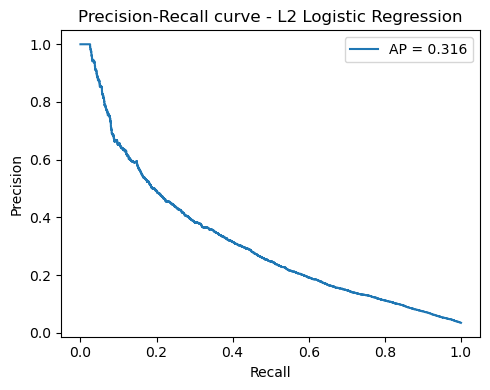

In [34]:
def plot_pr_roc_curves(y_true, y_proba, model_name="Model"):
    # ROC curve
    fpr, tpr, roc_thresholds = roc_curve(y_true, y_proba)
    roc_auc = roc_auc_score(y_true, y_proba)

    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate (Recall)")
    plt.title(f"ROC curve - {model_name}")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(f"images/ROC curve-{model_name}.png")
    plt.show()

    # Precision–Recall curve
    precision, recall, pr_thresholds = precision_recall_curve(y_true, y_proba)
    ap = average_precision_score(y_true, y_proba)

    plt.figure(figsize=(5,4))
    plt.plot(recall, precision, label=f"AP = {ap:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall curve - {model_name}")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.savefig(f"images/Precision-Recall curve-{model_name}.png")
    plt.show()

    return {
        "fpr": fpr, "tpr": tpr, "roc_thresholds": roc_thresholds,
        "precision": precision, "recall": recall, "pr_thresholds": pr_thresholds
    }

# Example usage for your L2 model
# y_valid_proba_l2 = logreg_l2.predict_proba(X_valid)[:, 1]
curves_l2 = plot_pr_roc_curves(y_valid, y_valid_proba_l2, model_name="L2 Logistic Regression")

In [35]:
### 11.4 Find a few candidate thresholds ###
def summarize_thresholds(y_true, y_proba, target_recalls=(0.6, 0.7, 0.8)):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    thresholds = np.append(thresholds, 1.0)  # align lengths

    results = []
    for tr in target_recalls:
        # find closest recall
        idx = np.argmin(np.abs(recall - tr))
        thr = thresholds[idx]
        prec = precision[idx]
        rec = recall[idx]
        results.append((thr, prec, rec))

    return results

threshold_summaries = summarize_thresholds(y_valid, y_valid_proba_l2)
for thr, prec, rec in threshold_summaries:
    print(f"Threshold ~{thr:.3f}: precision={prec:.3f}, recall={rec:.3f}")

Threshold ~0.614: precision=0.192, recall=0.600
Threshold ~0.518: precision=0.148, recall=0.700
Threshold ~0.425: precision=0.112, recall=0.800


In [36]:
chosen_thr = 0.518  # your middle threshold

y_valid_pred_thr = (y_valid_proba_l2 >= chosen_thr).astype(int)

print("Confusion matrix at threshold ~0.518:")
print(confusion_matrix(y_valid, y_valid_pred_thr))

print("\nClassification report at threshold ~0.518:")
print(classification_report(y_valid, y_valid_pred_thr, digits=4))

Confusion matrix at threshold ~0.518:
[[97297 16678]
 [ 1241  2892]]

Classification report at threshold ~0.518:
              precision    recall  f1-score   support

           0     0.9874    0.8537    0.9157    113975
           1     0.1478    0.6997    0.2440      4133

    accuracy                         0.8483    118108
   macro avg     0.5676    0.7767    0.5799    118108
weighted avg     0.9580    0.8483    0.8922    118108



**REMARKS:**
- Using the validation set, I examined the precision–recall trade‑off at different decision thresholds on the Logistic Regression fraud score.
- At a relatively conservative threshold of approximately 0.61, the model achieves 60% recall with 19% precision, while at an aggressive threshold of approximately 0.43 it reaches 80% recall but precision drops to 11%.
- As a balanced illustrative operating point, I focus on a threshold of approximately 0.52, where the model achieves around 70% recall and 15% precision on the fraud class.
- This threshold would allow a bank to intercept the majority of fraudulent transactions while maintaining a manageable volume of false positives for manual review or step‑up authentication.

## 12 Baseline Model results analysis ##

**1. What the metrics say**

- Overall, both models achieve ROC‑AUC ≈ 0.861, showing they rank fraudulent transactions well above non‑fraudulent ones across thresholds.
- PR‑AUC ≈ 0.316 (L2) and 0.315 (L1) is quite good given the base fraud rate of  around 3.5%: a random classifier would have PR‑AUC close to the base rate (~0.035), so we are doing ~9x better than random in terms of precision–recall trade‑off.
- Performance at threshold 0.5 using the confusion matrices:
    - L2 (very similar for L1):
    - True negatives: 95,763
    - False positives: 18,212
    - False negatives: 1,166
    - True positives: 2,967
- Interpretation:
    - Fraud recall is high: 0.718 (L2) and 0.717 (L1), meaning the model catches around 72% of known frauds at this threshold.
    - Fraud precision is low: ~0.14, meaning only ~14% of flagged transactions are actually fraudulent; ~86% of flags are false positives.
    - Overall accuracy ≈ 0.836 is not very meaningful here because the data is highly imbalanced; the model trades accuracy for much higher fraud recall by labelling more transactions as fraud.

-----------------------
**In business terms:** 

At this operating point, the model catches about 7 out of 10 frauds but flags many legitimate transactions for review/decline.

----------------------

**2. L2 vs L1 Comparison**
- ROC‑AUC: both 0.8612 (effectively identical).
- PR‑AUC: 0.3162 (L2) vs 0.3146 (L1) — a negligible difference.
- Confusion matrices and classification reports differ by only a handful of cases.
- Essentially,
    - L2 can be our main baseline (slightly better PR‑AUC, very stable) &
    - L1 can be presented as a sparser, interpretability‑oriented variant with essentially the same performance but fewer non‑zero coefficients.

-----------------------
**In business terms:** 

Both L1‑ and L2‑regularised Logistic Regression achieved ROC‑AUC of 0.861 and PR‑AUC around 0.315 on the validation set, demonstrating good ranking ability. At a 0.5 decision threshold, the L2 model reached 71.8% recall on the fraud class but only 14.0% precision, illustrating the trade‑off between catching more frauds and the number of false alerts in this highly imbalanced setting.

----------------------
